In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import ast
import pickle
from scipy import stats
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import gridspec
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Rectangle
from matplotlib import cbook

%matplotlib inline
# %matplotlib qt

font = { 'weight' : 'bold',
        'size'   : 16}
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{braket}')
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rc('text', usetex=True)
plt.rc('font', **font)
plt.rcParams['savefig.dpi'] = 300

In [55]:
# Parameters to match your Julia output filenames
N = 20
hx = 0.9045
hz = 0.809
J  = 1.0
tau = 20.0

J_res = 4*J
hx_res = 2*hx 
hz_res = 2*hz

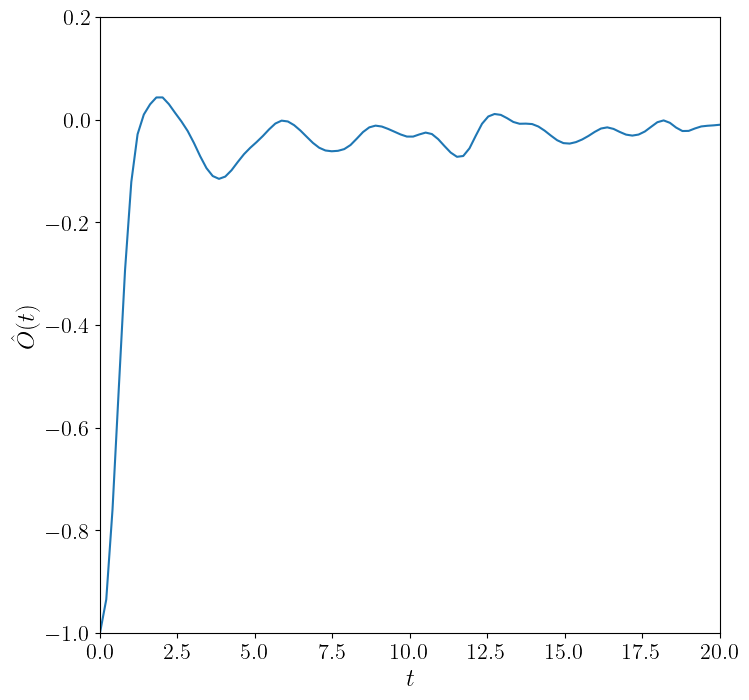

In [44]:
file = f"./ED_obs_time_N=10_tau={tau}_J={J}_hx={hx}_hz={hz}.csv"

df_ed = pd.read_csv(file)

time = np.array(df_ed["time"])
O = df_ed["O"]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.set_xlabel(r"$t$", fontsize = 18)
ax.set_ylabel(r"$\hat{O}(t)$", fontsize = 18)

ax.set_ylim(-1, 0.2)
ax.set_xlim(0.0, np.max(time))
ax.plot(time, O)

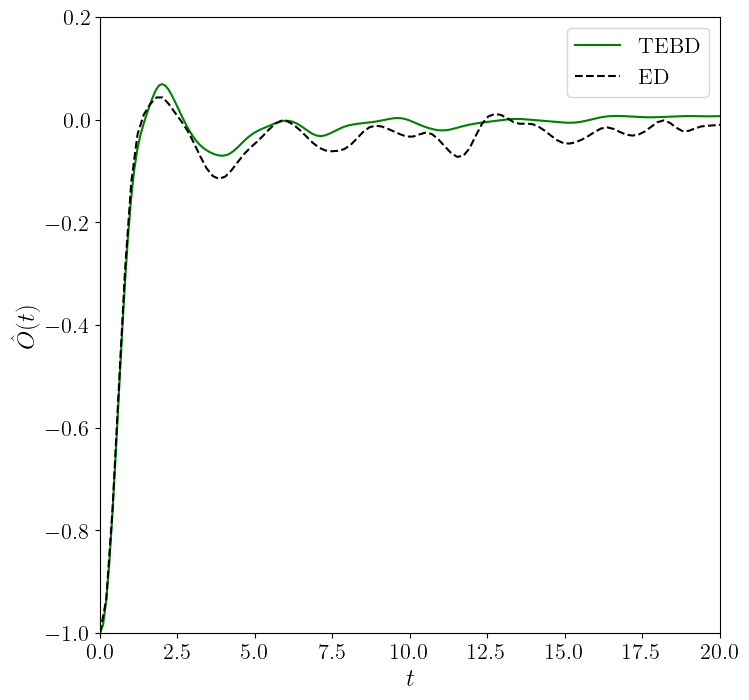

In [57]:
dt = 0.1

file = f"./TEBD_obs_time_N={N}_tau={tau}_dt={dt}_J={J_res:.1f}_hx={hx_res:.3f}_hz={hz_res:.3f}.csv"

df = pd.read_csv(file)

time = np.array(df["time"])
O = df["O"]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.set_xlabel(r"$t$", fontsize = 18)
ax.set_ylabel(r"$\hat{O}(t)$", fontsize = 18)

ax.set_ylim(-1, 0.2)
ax.set_xlim(0.0, np.max(time))

ax.plot(time, O, "-", color = "green", label = "TEBD")
ax.plot(df_ed["time"], df_ed["O"], "--", color = "black", label = "ED")
ax.legend()